## Introduction to Quantum Computing: Labs

### Lab 3: Multiple Qubits and Measurements

### Parameterized Circuits in Qiskit

Qiskit also allows using free parameters for the angles of rotation gates.

Free parameters can be created using the ``ParameterVector(name, count)`` class from Qiskit:

```python
p = ParameterVector('θ', 3)
```

The variable ``p`` is now a list with 3 entries; individual parameters can be addressed using ``p[0]`` etc.
These parameters can be used as angles in rotation gates:

```python
quantum_circuit.rx(p[0], 0)
```

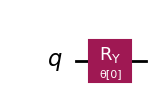

In [55]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

# Initializes an empty quantum circuit with one qubit
quantum_circuit = QuantumCircuit(1)

# Qiskit also offers the possibility to use free parameters for parameterized gates
p = ParameterVector('θ', 1)
# Adds a parametric rotation gate around the Y-axis
quantum_circuit.ry(p[0], 0)  

# Generates a visual representation of the circuit
quantum_circuit.draw('mpl')

The resulting quantum state of a quantum circuit can be visualized using the Bloch sphere. We use the helper function ``sv_interactive_blochsphere`` for this and pass the quantum circuit to it.
If the circuit contains free parameters, they can be changed interactively.

In [56]:
from qc_lecture_tools.statevector import sv_interactive_blochsphere, sv_state

sv_interactive_blochsphere(quantum_circuit)

### Exercise 1: Playing around with rotation gates

We will now use the code from above to experiment with rotation gates.

**Exercise 1.1:** Find a rotation gate and a suitable angle to rotate the quantum state to $\ket{1}$ (this corresponds to the South Pole). The starting point is always the North Pole with the $\ket{0}$ state.

In [57]:
quantum_circuit = QuantumCircuit(1)

p = ParameterVector('θ', 1)
quantum_circuit.ry(p[0], 0)
sv_interactive_blochsphere(quantum_circuit) # Change angle to 1.0pi


**Exercise 1.2:** Now find a rotation gate and a suitable angle to rotate the quantum state to the X-axis (where the x is in the diagram).

In [58]:
quantum_circuit = QuantumCircuit(1)

p = ParameterVector('θ', 1)
quantum_circuit.ry(p[0], 0)
sv_interactive_blochsphere(quantum_circuit) # Change angle to 0.5pi


**Exercise 1.3:** Now find a rotation gate and a suitable angle to rotate the quantum state to the Y-axis (where the y is in the diagram).

In [59]:
quantum_circuit = QuantumCircuit(1)

p = ParameterVector('θ', 1)
quantum_circuit.rx(p[0], 0)
sv_interactive_blochsphere(quantum_circuit) # Change angle to -0.5pi


### Exercise 2: Multiple Qubits

We can build a quantum circuit with multiple qubits in Qiskit as follows:

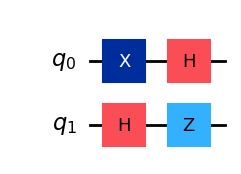

<IPython.core.display.Math object>

In [60]:
# Initializes an empty quantum circuit with two qubits
quantum_circuit = QuantumCircuit(2)

# Gates for Qubit 1
quantum_circuit.x(0)
quantum_circuit.h(0)

# Gates for Qubit 2
quantum_circuit.h(1)
quantum_circuit.z(1)

display(quantum_circuit.draw('mpl'))
display(sv_state(quantum_circuit, "Quantum State: "))


**Exercise 2.1:** Find a circuit that builds the following state (only one gate is necessary):
$\ket{\Psi_1} = \frac{\sqrt{2}}{2} \ket{00} + \frac{\sqrt{2}}{2} \ket{10}$

In [61]:
# TODO Exercise 2.1

**Exercise 2.2:** Now a circuit that builds a similar state, but the values are swapped:
$\ket{\Psi_2} = \frac{\sqrt{2}}{2} \ket{00} + \frac{\sqrt{2}}{2} \ket{01}$

In [62]:
# TODO Exercise 2.2

**Exercise 2.3:** What happens if I apply a Hadamard gate to Qubit 1 and Qubit 2 respectively?

In [63]:
# TODO Exercise 2.3

**Exercise 2.4:** What does it look like for three qubits? What do you observe here?

In [64]:
# TODO Exercise 2.4

**Exercise 2.5:** We go back to two qubits and start again with the state from Exercise 2.2 (two Hadamard gates on Qubit 1 and Qubit 2).

Investigate what happens to the quantum state if you now apply a Pauli-Z gate to Qubit 1?

What does it look like if the Pauli-Z gate is applied to Qubit 2?

What do you expect if you apply the Z gate to both qubits?

(Reminder: $Z\ket{0}= \ket0$ and $Z\ket{1}= -\ket{1}$)

In [65]:
# TODO Exercise 2.5

**Exercise 2.6:** 
In the following Exercises, we apply the knowledge from Exercise 2.5.
Find a circuit for the following state:
$\frac{1}{2} \ket{00} + \frac{1}{2} \ket{01} + \frac{i}{2} \ket{10} + \frac{i}{2} \ket{11}$

**Hint:** $S\ket{0} = \ket{0}$ and $S\ket{1} = i\ket{1}$

In [66]:
# TODO Exercise 2.6

**Exercise 2.7:** Find a circuit for the following state:
$\frac{1}{2} \ket{00} + \frac{i}{2} \ket{01} + \frac{1}{2} \ket{10}  + \frac{i}{2} \ket{11}$

In [67]:
# TODO Exercise 2.7

**Exercise 2.8:** Find a circuit for the following state:
$\frac{1}{2} \ket{00} + \frac{i}{2} \ket{01} + \frac{i}{2} \ket{10}  -\frac{1}{2} \ket{11}$

In [68]:
# TODO Exercise 2.8

### Exercise 3: Combining Quantum States with the Tensor Product

**Reminder:** The tensor product of two states $\ket{\psi_1}$ and $\ket{\psi_2}$ is formed as follows:

$\ket{\psi_1} \otimes \ket{\psi_2} = (\alpha_1 \ket{0} + \beta_1 \ket{1}) \otimes (\alpha_2 \ket{0} + \beta_2 \ket{1}) = \alpha_1 \beta_1 \ket{00} + \alpha_1 \beta_2 \ket{01} + \beta_1\alpha_2  \ket{10} + \beta_1 \beta_2 \ket{11}$

This allows two 1-qubit states to be combined into a 2-qubit state.

With the helper function ``sv_tensor``, we can combine any two quantum states in Python.

In [69]:
# Example for using sv_tensor
from qc_lecture_tools.statevector import sv_tensor

quantum_circuit1 = QuantumCircuit(1)
quantum_circuit1.h(0)

quantum_circuit2 = QuantumCircuit(1)
quantum_circuit2.x(0)

sv_tensor(quantum_circuit1, quantum_circuit2)

<IPython.core.display.Math object>

**Exercise 3.1:** What happens if you combine the following quantum states:

```python
quantum_circuit1 = QuantumCircuit(1)
quantum_circuit1.x(0)
quantum_circuit1.h(0)
```

and

```python
quantum_circuit2 = QuantumCircuit(1)
quantum_circuit2.h(0)
quantum_circuit2.z(0)
```

Compare the result with the entire two-qubit circuit, with the same gates applied


In [70]:
quantum_circuit1 = QuantumCircuit(1)
quantum_circuit1.x(0)
quantum_circuit1.h(0)

quantum_circuit2 = QuantumCircuit(1)
quantum_circuit2.h(0)
quantum_circuit2.z(0)

# TODO Exercise 3.1

**Exercise 3.2:** Now we do the same with rotation gates:

```python
quantum_circuit1 = QuantumCircuit(1)
quantum_circuit1.ry(270*np.pi/180,0)
```

and

```python
quantum_circuit2 = QuantumCircuit(1)
quantum_circuit2.ry(60*np.pi/180,0)
```
What happens here with the measurement probabilities of the individual single qubit states and
the two-qubit state? (``sv_probs``)

In [71]:
# Example for using sv_probs

from qc_lecture_tools.statevector import sv_probs
quantum_circuit = QuantumCircuit(2)
quantum_circuit.x(0)
display(sv_probs(quantum_circuit, " Measurement Probabilities"))

<IPython.core.display.Math object>

In [72]:
# TODO Exercise 3.2

### Exercise 4: Measurements

So far we have only looked at the mathematical formula of quantum states. In fact, we cannot observe these directly, but only approximate the probabilities through statistical measurements.

To introduce measurements in Qiskit, we first define classical bits in which we can store the result of measurements. The first argument of QuantumCircuit contains
the number of qubits, the second argument the number of classical bits:

```python
QuantumCircuit(num_qubits, num_bits)
```

Measurements can now be added in Qiskit with the ``measure`` function:

```python
quantum_circuit.measure(0,0)
```
The first index here is the qubit to be measured, the second index is the classical bit.


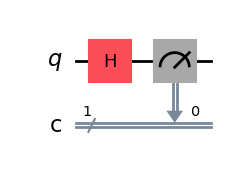

In [73]:
# This is what the code looks like in Qiskit
quantum_circuit = QuantumCircuit(1,1)
quantum_circuit.h(0)
quantum_circuit.measure(0,0)
quantum_circuit.draw('mpl')

In Qiskit, a so-called classical register named ``c`` is added, where the measured bits (1 or 0) are stored.
The double lines mean that the information is no longer a quantum state but purely classical information in the form of 0 or 1.

**Exercise 4.1:** Create a quantum circuit in which two qubits are brought into superposition with Hadamard gates and then measured.

In [74]:
# TODO Exercise 4.1

#### Simulated Measurements with Qiskit

Now we want to start with the measurements. To do this, one must first decide how often to measure. In technical terminology, the term ``shots`` is also used for a measurement.
The number of measurements determines the accuracy with which we can approximate our measurement probabilities.

The result of our measurements is a series of measured bitstrings (combinations of 1s and 0s). These are often summarized in Python dictionaries:

```python
result = {"00":15, "01":20, "10":35, "11":30}
```

Since the Qiskit syntax is intended to be executed on a real quantum computer and is accordingly complicated, we will use a helper function again for now:

```python
sample_from_circuit(quantum_circuit, num_shots=1024)
```

The number of measurements can be set with ``num_shots`` (0 is not allowed). As a result, you get back a Python dictionary with the count of measured states.


In [75]:
from qc_lecture_tools.sampling import sample_from_circuit

quantum_circuit = QuantumCircuit(2,2)
quantum_circuit.h(0)
quantum_circuit.x(0)

display(sv_state(quantum_circuit, "Quantum State:"))
display(sv_probs(quantum_circuit, " Measurement probabilities before measurement:"))

quantum_circuit.measure(0,0)
quantum_circuit.measure(1,1)

sample_from_circuit(quantum_circuit, num_shots=1000)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

{'00': 495, '10': 505}

**Exercise 4.2:** First build a quantum circuit with two qubits with equal probability for all states and measure both qubits.
Use the function `sample_from_circuit` to perform 500 measurements.

In [76]:
# TODO Exercise 4.2

**Exercise 4.3:** Calculate the measured probabilities from the measurement results.

**Hint 1:** The probabilities are obtained by dividing the number of measurements of the individual state by the total number of measurements.

If you like, you can write a Python function for this:
```python
def measure_to_probs(results_dict):
    #TODO
    return probs # Also dictionary, only with measured probabilities
```

**Hint 2:** Python dictionaries can be used as follows:

In [77]:
results = {"00":15, "01":20, "10": 35, "11":30}

print("Number of measurements for state 00:",results["00"])
print("Measured states:", results.keys())
print("All measurement values:", results.values())

# Loop over all measured states
for state in results.keys():
    print(f"State {state} was measured {results[state]} times.")

# Empty dictionary:
results = {}
# Add new entry:
results["00"] = 15

Number of measurements for state 00: 15
Measured states: dict_keys(['00', '01', '10', '11'])
All measurement values: dict_values([15, 20, 35, 30])
State 00 was measured 15 times.
State 01 was measured 20 times.
State 10 was measured 35 times.
State 11 was measured 30 times.


In [78]:
def measure_to_probability(results_dict):
    #TODO Exercise 4.3
    probs={} # Empty dictionary for probabilities
    return probs # Also dictionary, only with measured probabilities

In [79]:
measurements = sample_from_circuit(quantum_circuit, num_shots=500)

measure_to_probability(measurements)

{}

**Exercise 4.4:** Repeat Exercise 4.3 for a different number of measurements
(e.g., 100, 500, 1000, 5000, 10000) and compare the measured probabilities with the theoretical ones (here 0.25).

To do this, calculate the difference between the measured and the theoretical probabilities.

**Hint:** If you have not yet implemented the function ``measure_to_probability`` yourself in Exercise 4.3, you can import it from the helper library here.

In [80]:
from qc_lecture_tools.sampling import measure_to_probability

In [81]:
# TODO Exercise 4.4

**Bonus Exercise (more difficult):** To analyze the relationship between the errors and the number of measurements more precisely, create a plot with ``matplotlib``: on the x-axis the number of measurements, on the y-axis the error. You can do it for one of the 4 states or sum over all errors.

**Hint 1:** Take the absolute error without sign (``np.abs(-1)=1``).

**Hint 2:** Since the deviations (variance) are very high with few measurements, one can also repeat the measurements and average them, then one gets a nicer and more accurate curve.

**Hint 3:** The sum over a list can be formed in Python with ``sum()``.

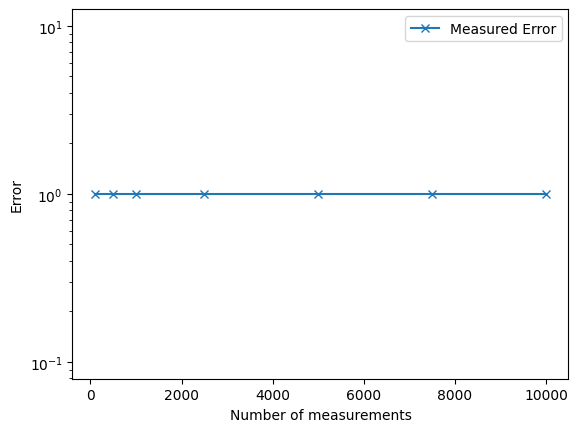

In [82]:
# Frame for the plot

x_shots = [100,500,1000,2500,5000,7500,10000]
y_error =[]

for shots in x_shots:
    #TODO: Calculate the error for a state (e.g., "00" or the sum over all errors) and add it to y_error
    y_error.append(1.0)

import matplotlib.pyplot as plt
plt.semilogy(x_shots, y_error, '-x', label="Measured Error")

plt.xlabel("Number of measurements")
plt.ylabel("Error")
plt.legend()

In [83]:
# TODO Bonus Exercise